# CNN Image Classification — Full Pipeline

End-to-end deep learning pipeline in Google Colab:

1. Mount Google Drive
2. Load image dataset
3. Preprocess images
4. Train / Validation / Test split
5. Build CNN model
6. Train the model
7. Evaluate the model
8. Predict on test images
9. Display evaluation metrics
10. Plot all important curves
11. Save the trained model

**Before running:** organize your dataset in Google Drive as one folder per class:

```
DATASET_DIR/
    class_1/
        img1.jpg
        img2.jpg
    class_2/
        img1.jpg
        ...
```
Then set `DATASET_DIR` in the configuration cell below.


## 0. Imports

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Mount Google Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configuration & Load Dataset

Edit `DATASET_DIR` to point at your dataset folder in Drive.

In [13]:
# ================================
# CONFIGURATION - EDIT THIS SECTION
# ================================
DATASET_DIR = "/content/drive/MyDrive/Mango leaf dataset"   # <-- change this to your dataset path
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 40

class_names = sorted(os.listdir(DATASET_DIR))
NUM_CLASSES = len(class_names)
print("Classes found:", class_names)
print("Number of classes:", NUM_CLASSES)


Classes found: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Number of classes: 8


In [14]:
# Collect file paths and integer labels
filepaths, labels = [], []

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            filepaths.append(os.path.join(class_dir, fname))
            labels.append(idx)

filepaths = np.array(filepaths)
labels = np.array(labels)
print("Total images found:", len(filepaths))


Total images found: 4000


### Class Distribution

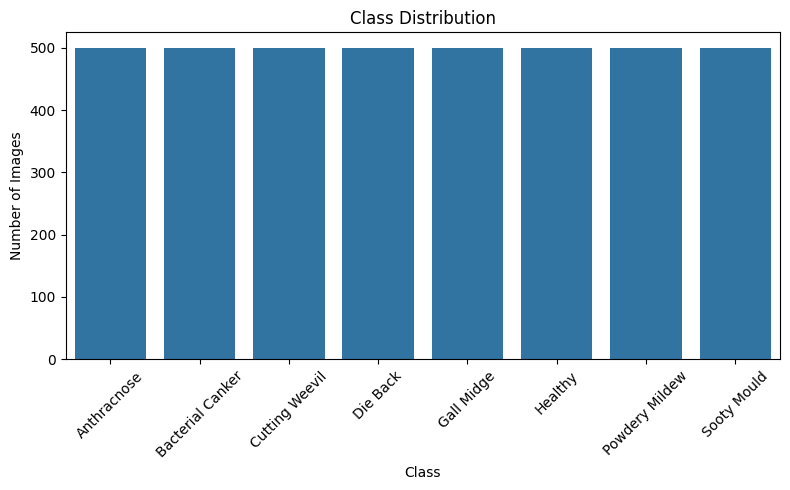

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x=[class_names[l] for l in labels])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Train / Validation / Test Split (70 / 15 / 15, stratified)

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print("Train:", len(X_train), " Val:", len(X_val), " Test:", len(X_test))


Train: 2800  Val: 600  Test: 600


## 4. Preprocessing Pipeline (resize, normalize, augment)

In [17]:
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image, label

def make_dataset(paths, lbls, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        augmenter = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
            tf.keras.layers.RandomZoom(0.05),
        ])
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

# Create Dataset
train_ds = make_dataset(X_train, y_train, shuffle=True, augment=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

## 5. Build the CNN Model

In [18]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,184 (1.75 MB)

 Trainable params: 457,224 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Train the Model

In [19]:
# Cosine Decay Learning Rate Scheduler ready
decay_steps = EPOCHS * len(train_ds)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=decay_steps
)

# Callback setup
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/best_model.keras", monitor='val_accuracy', save_best_only=True
)

# Again compile model using schedular
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.6675 - loss: 1.0383 - val_accuracy: 0.1333 - val_loss: 2.5017
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 168ms/step - accuracy: 0.8457 - loss: 0.5142 - val_accuracy: 0.2083 - val_loss: 2.9647
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 165ms/step - accuracy: 0.8886 - loss: 0.3875 - val_accuracy: 0.5333 - val_loss: 1.2388
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 0.9004 - loss: 0.3146 - val_accuracy: 0.9283 - val_loss: 0.2805
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.9132 - loss: 0.2900 - val_accuracy: 0.9467 - val_loss: 0.1945
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.9339 - loss: 0.2238 - val_accuracy: 0.9083 - val_loss: 0.2286
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.9425 - loss: 0.2087 - val_accuracy: 0.9667 - val_loss: 0.1552
Epoch 8/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - accuracy: 0.9432 - loss: 0

## 7. Training Curves — Accuracy & Loss

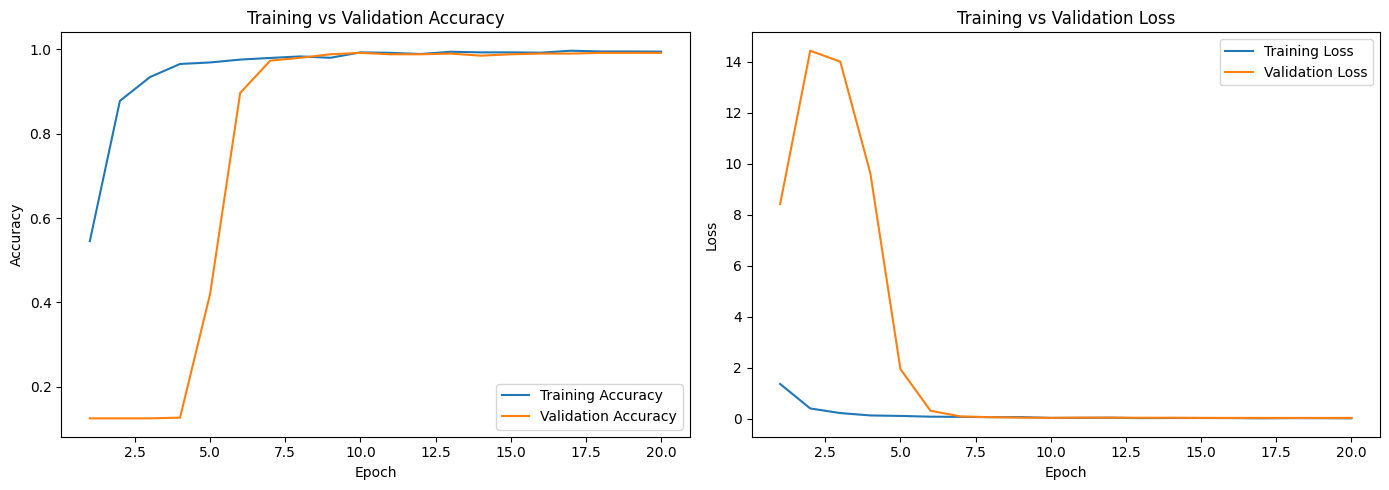

Final Training Accuracy   : 0.9946
Final Validation Accuracy : 0.9917
Final Training Loss       : 0.0150
Final Validation Loss     : 0.0312


In [34]:
import matplotlib.pyplot as plt

# Collect form history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Final matrics print
print(f"Final Training Accuracy   : {acc[-1]:.4f}")
print(f"Final Validation Accuracy : {val_acc[-1]:.4f}")
print(f"Final Training Loss       : {loss[-1]:.4f}")
print(f"Final Validation Loss     : {val_loss[-1]:.4f}")

## 8. Evaluate the Model on the Test Set

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss             : {test_loss:.4f}")
print(f"Test Accuracy (Top-1) : {test_accuracy:.4f}")


38/38 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9983 - loss: 0.0194
Test Loss             : 0.0194
Test Accuracy (Top-1) : 0.9983


## 9. Predict on Test Images

In [22]:
y_true = y_test
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


## 10. Evaluation Metrics

In [23]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)   # Sensitivity
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

# Specificity per class (one-vs-rest), then macro-averaged
specificities = []
for i in range(NUM_CLASSES):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificities.append(tn / (tn + fp + 1e-10))
specificity = np.mean(specificities)

print("=" * 50)
print("EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision (macro)    : {precision:.4f}")
print(f"Recall / Sensitivity : {recall:.4f}")
print(f"F1-score (macro)     : {f1:.4f}")
print(f"Specificity (macro)  : {specificity:.4f}")
print(f"Balanced Accuracy    : {bal_acc:.4f}")
print(f"Cohen's Kappa        : {kappa:.4f}")
print(f"MCC                  : {mcc:.4f}")
print(f"Top-1 Accuracy       : {test_accuracy:.4f}")
print(f"Test Loss            : {test_loss:.4f}")
print("=" * 50)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


EVALUATION METRICS
Accuracy             : 0.9983
Precision (macro)    : 0.9984
Recall / Sensitivity : 0.9983
F1-score (macro)     : 0.9983
Specificity (macro)  : 0.9998
Balanced Accuracy    : 0.9983
Cohen's Kappa        : 0.9981
MCC                  : 0.9981
Top-1 Accuracy       : 0.9983
Test Loss            : 0.0194

Classification Report:

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       0.99      1.00      0.99        75
  Cutting Weevil       1.00      1.00      1.00        75
        Die Back       1.00      1.00      1.00        75
      Gall Midge       1.00      0.99      0.99        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       1.00      1.00      1.00        75
     Sooty Mould       1.00      1.00      1.00        75

        accuracy                           1.00       600
       macro avg       1.00      1.00      1.00       600
    weighted avg

### Confusion Matrix (Heatmap)

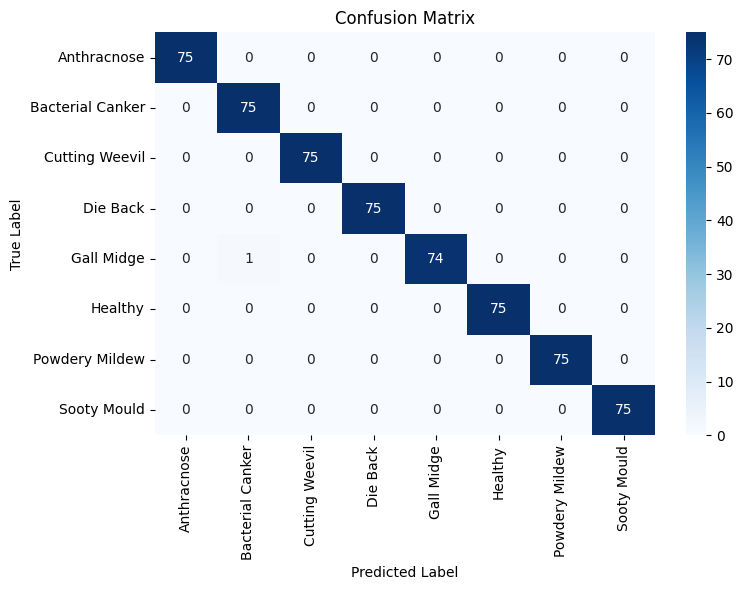

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### ROC Curve & AUC Score (one-vs-rest per class)

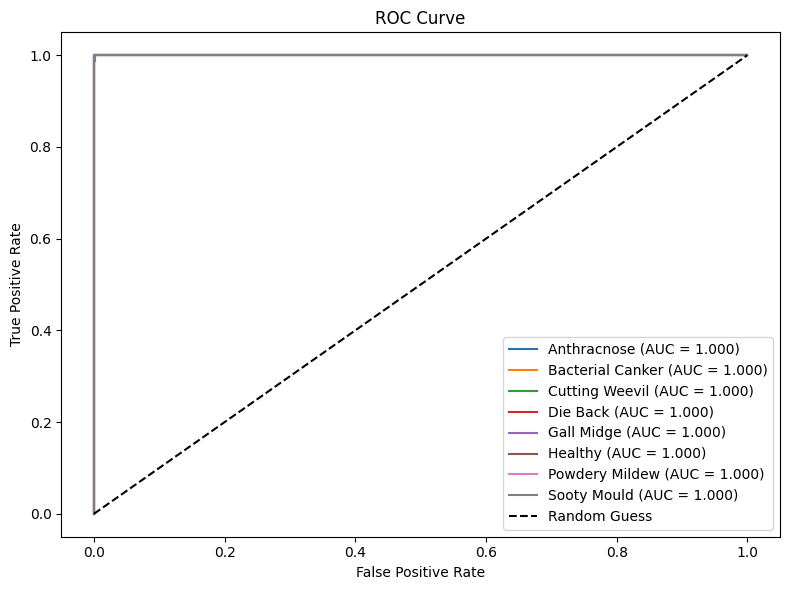

Mean AUC Score: 1.0000


In [25]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
if NUM_CLASSES == 2:
    y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

mean_auc = np.mean(list(roc_auc.values()))
print(f"Mean AUC Score: {mean_auc:.4f}")


### Precision-Recall Curve

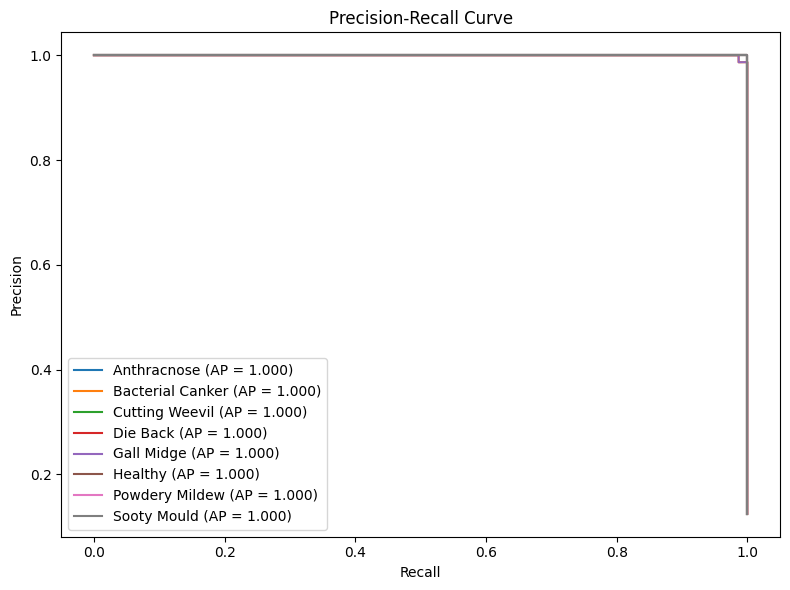

Mean Average Precision: 1.0000


In [26]:
plt.figure(figsize=(8, 6))
avg_precisions = []
for i in range(NUM_CLASSES):
    prec_i, rec_i, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ap_i = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    avg_precisions.append(ap_i)
    plt.plot(rec_i, prec_i, label=f'{class_names[i]} (AP = {ap_i:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f"Mean Average Precision: {np.mean(avg_precisions):.4f}")


### Sample Predictions

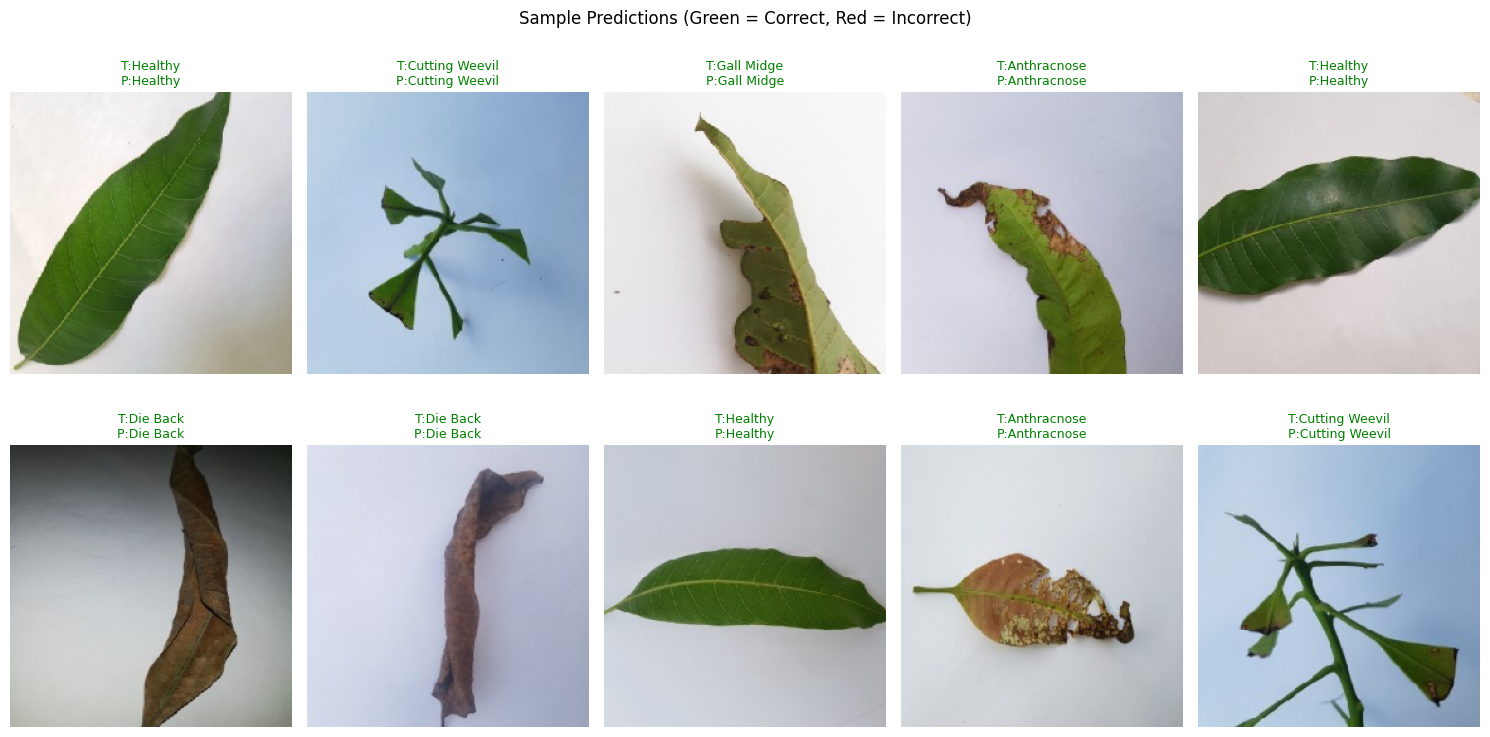

In [27]:
plt.figure(figsize=(15, 8))
sample_idx = np.random.choice(len(X_test), size=min(10, len(X_test)), replace=False)

for i, idx in enumerate(sample_idx):
    img = load_img(X_test[idx], target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Sample Predictions (Green = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()


### Misclassified Images

Total misclassified images: 1 out of 600


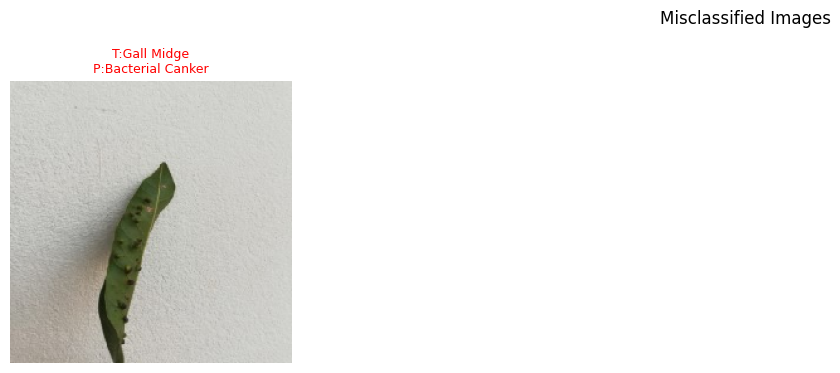

In [28]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_true)}")

if len(misclassified_idx) > 0:
    show_idx = misclassified_idx[:10]
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(show_idx):
        img = load_img(X_test[idx], target_size=(IMG_HEIGHT, IMG_WIDTH))
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"T:{true_label}\nP:{pred_label}", color='red', fontsize=9)
        plt.axis('off')
    plt.suptitle("Misclassified Images")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images!")


## 11. Save the Trained Model

In [29]:
SAVE_DIR = "/content/drive/MyDrive/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "cnn_model.keras"))
model.save(os.path.join(SAVE_DIR, "cnn_model.h5"))

print("Model saved to:")
print(" -", os.path.join(SAVE_DIR, "cnn_model.keras"))
print(" -", os.path.join(SAVE_DIR, "cnn_model.h5"))


Model saved to:
 - /content/drive/MyDrive/saved_models/cnn_model.keras
 - /content/drive/MyDrive/saved_models/cnn_model.h5


## Notes

- **Multi-class metrics**: Precision, Recall, F1, and Specificity are macro-averaged across classes. ROC/AUC and Precision-Recall curves are computed one-vs-rest per class, with a mean AUC / mean Average Precision reported.
- **Binary classification**: if `NUM_CLASSES == 2`, all the same code paths work — the second class's curve is the one usually reported.
- Adjust `IMG_HEIGHT`, `IMG_WIDTH`, `BATCH_SIZE`, and `EPOCHS` in the configuration cell to fit your dataset size and Colab runtime (GPU recommended: **Runtime → Change runtime type → GPU**).


## ResNet50 Model Build

In [30]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# Pre-train ResNet50 (224x224 input)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Backbone on for fine tune
base_model.trainable = True

# Attach custom head
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='softmax')
])

# Compile with low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Model Train and Save

In [31]:
import gc
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, Callback

# Custom callback for clear RAM
class ClearMemoryCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        tf.keras.backend.clear_session()

# Checkpoint
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/saved_models/resnet50_mango.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Dynamic re-user
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Model train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, lr_reducer, ClearMemoryCallback()]
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.3675 - loss: 2.0129
Epoch 1: val_accuracy improved from None to 0.12500, saving model to /content/drive/MyDrive/saved_models/resnet50_mango.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/resnet50_mango.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 430ms/step - accuracy: 0.5454 - loss: 1.3632 - val_accuracy: 0.1250 - val_loss: 8.4191 - learning_rate: 1.0000e-05
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8568 - loss: 0.4888
Epoch 2: val_accuracy did not improve from 0.12500
175/175 ━━━━━━━━━━━━━━━━━━━━ 147s 409ms/step - accuracy: 0.8779 - loss: 0.4023 - val_accuracy: 0.1250 - val_loss: 14.4357 - learning_rate: 1.0000e-05
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9224 - loss: 0.2475
Epoch 3: val_accuracy did not improve from 0.12500
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 413ms/step - accuracy: 0.9343 - loss: 0.2213 - val_accuracy: 0.1250 - val_loss: 14.0

## Training Curves (Accuracy & Loss Curve)

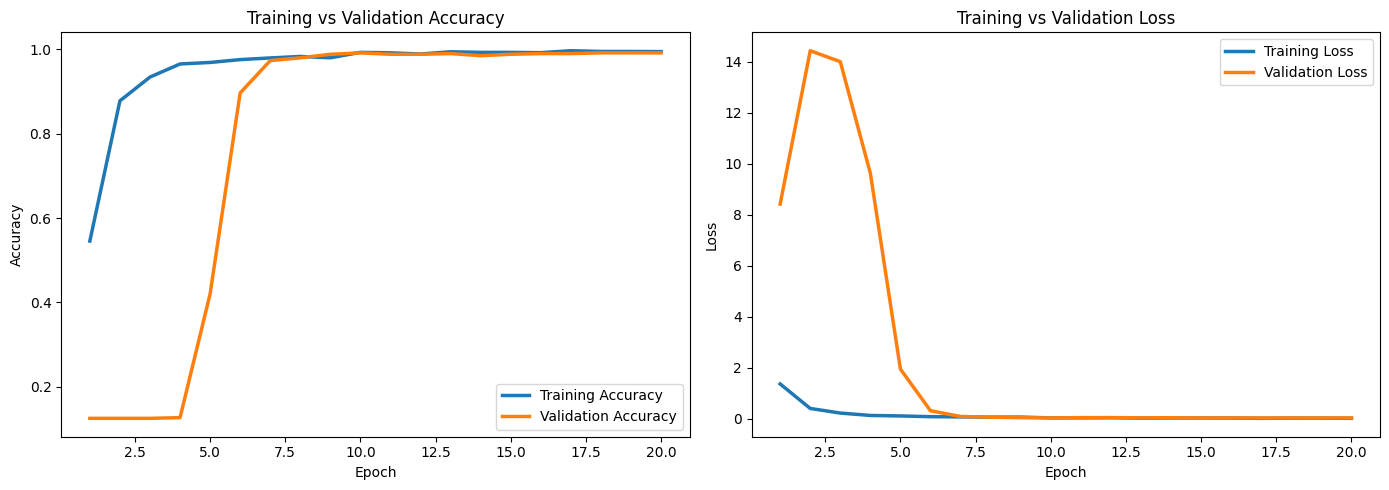

Final Training Accuracy   : 0.9946
Final Validation Accuracy : 0.9917
Final Training Loss       : 0.0150
Final Validation Loss     : 0.0312


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# ইতিহাস থেকে মেট্রিক্স নেওয়া
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2.5)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2.5)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2.5)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2.5)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Final metrics print
print(f"Final Training Accuracy   : {acc[-1]:.4f}")
print(f"Final Validation Accuracy : {val_acc[-1]:.4f}")
print(f"Final Training Loss       : {loss[-1]:.4f}")
print(f"Final Validation Loss     : {val_loss[-1]:.4f}")